In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Dataset Loaded

In [3]:
df = pd.read_csv("../data/processed/cleaned_banking_churn.csv")
df.head()

,age,gender,dependents,occupation,customer_nw_category,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction,customer_tenure_years
0,66,Male,0,self_employed,2,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21,5.76
1,35,Male,0,self_employed,2,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01,6.43
2,31,Male,0,salaried,2,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaN,6.01
3,90,Male,0,self_employed,2,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06,6.38
4,42,Male,2,self_employed,3,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03,4.33


### Data Overview

In [4]:
df.shape

(28382, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             28382 non-null  int64  
 1   gender                          28382 non-null  object 
 2   dependents                      28382 non-null  int64  
 3   occupation                      28382 non-null  object 
 4   customer_nw_category            28382 non-null  int64  
 5   current_balance                 28382 non-null  float64
 6   previous_month_end_balance      28382 non-null  float64
 7   average_monthly_balance_prevQ   28382 non-null  float64
 8   average_monthly_balance_prevQ2  28382 non-null  float64
 9   current_month_credit            28382 non-null  float64
 10  previous_month_credit           28382 non-null  float64
 11  current_month_debit             28382 non-null  float64
 12  previous_month_debit            

In [6]:
df.describe()

,age,dependents,customer_nw_category,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,customer_tenure_years
count,28382.000000,28382.000000,28382.000000,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,28382.000000,28382.000000
mean,48.208336,0.310232,2.225530,7.380552e+03,7.495771e+03,7.496780e+03,7.124209e+03,3.433252e+03,3.261694e+03,3.658745e+03,3.339761e+03,7.451133e+03,7.495177e+03,0.185329,5.729142
std,17.807163,0.797299,0.660443,4.259871e+04,4.252935e+04,4.172622e+04,4.457581e+04,7.707145e+04,2.968889e+04,5.198542e+04,2.430111e+04,4.203394e+04,4.243198e+04,0.388571,0.747067
min,1.000000,0.000000,1.000000,-5.503960e+03,-3.149570e+03,1.428690e+03,-1.650610e+04,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,-3.374180e+03,-5.171920e+03,0.000000,0.200000
25%,36.000000,0.000000,2.000000,1.784470e+03,1.906000e+03,2.180945e+03,1.832507e+03,3.100000e-01,3.300000e-01,4.100000e-01,4.100000e-01,1.996765e+03,2.074407e+03,0.000000,5.360000
50%,46.000000,0.000000,2.000000,3.281255e+03,3.379915e+03,3.542865e+03,3.359600e+03,6.100000e-01,6.300000e-01,9.193000e+01,1.099600e+02,3.447995e+03,3.465235e+03,0.000000,5.900000
75%,60.000000,0.000000,3.000000,6.635820e+03,6.656535e+03,6.666887e+03,6.517960e+03,7.072725e+02,7.492350e+02,1.360435e+03,1.357553e+03,6.667958e+03,6.654693e+03,0.000000,6.280000
max,90.000000,9.000000,3.000000,5.905904e+06,5.740439e+06,5.700290e+06,5.010170e+06,1.226985e+07,2.361808e+06,7.637857e+06,1.414168e+06,5.778185e+06,5.720144e+06,1.000000,6.780000


============================================================
## 1. TARGET VARIABLE ANALYSIS
============================================================


In [7]:
(df["churn"].value_counts(normalize = True)*100).round

<bound method Series.round of churn
0    81.467127
1    18.532873
Name: proportion, dtype: float64>

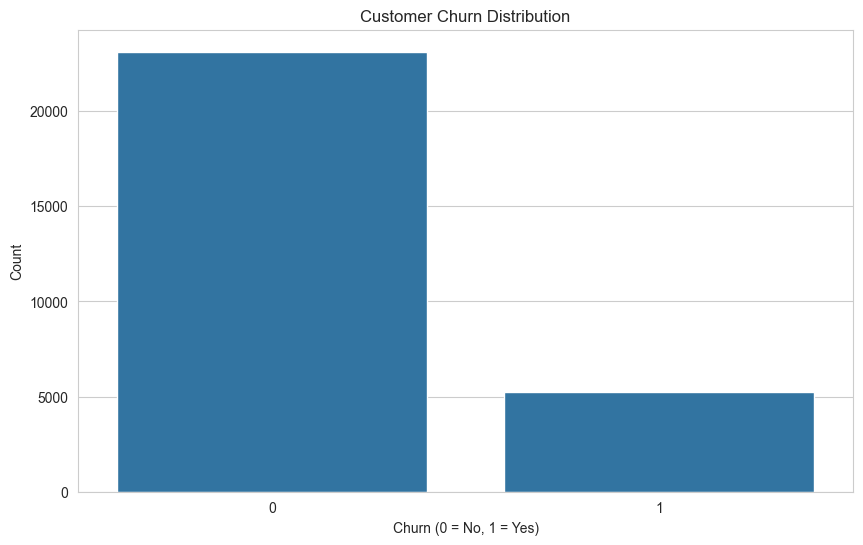

In [8]:
sns.countplot(x="churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

## MARKDOWN:
#### Churn rate is approximately 18.5%.
#### Dataset is moderately imbalanced.


============================================================
## 2. UNIVARIATE ANALYSIS
============================================================

### Age Distribution

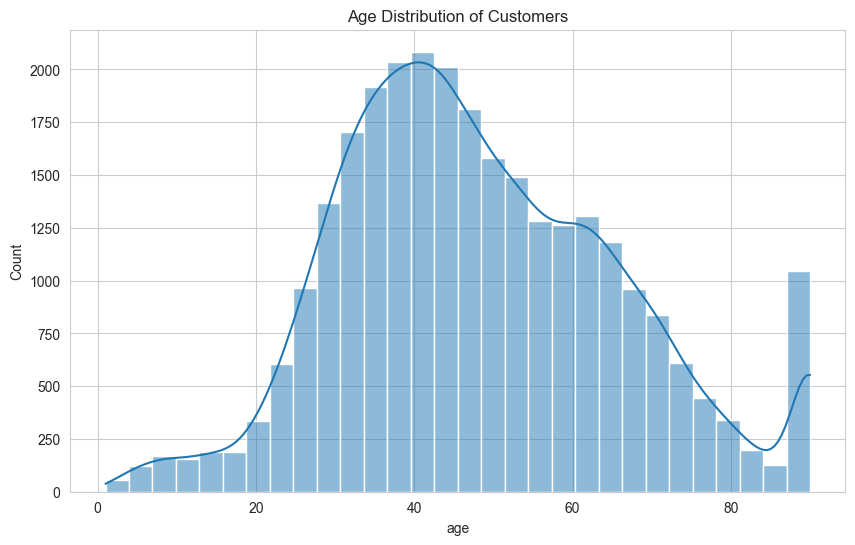

In [9]:
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution of Customers")
plt.show()

# MARKDOWN:
### Majority customers fall between ages 30–60.

# GENDER DISTRIBUTION

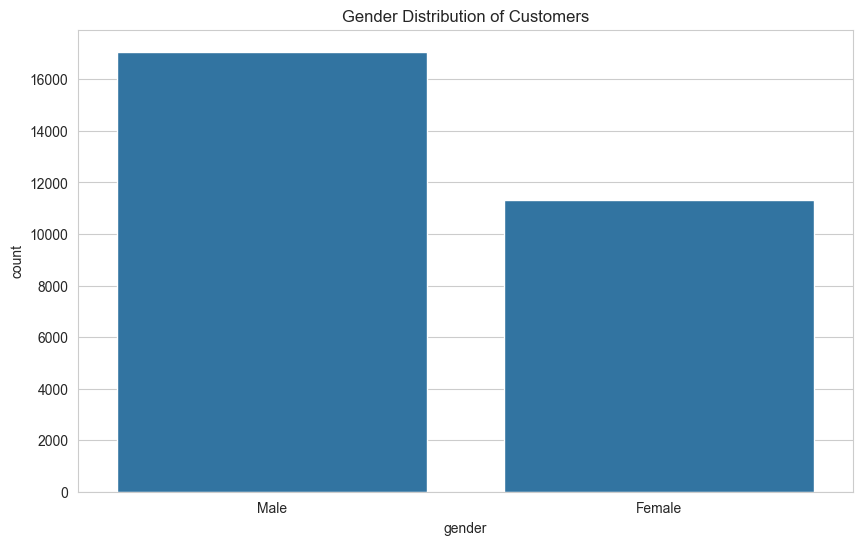

In [10]:
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution of Customers")
plt.show()

# OCCUPATION DISTRIBUTION

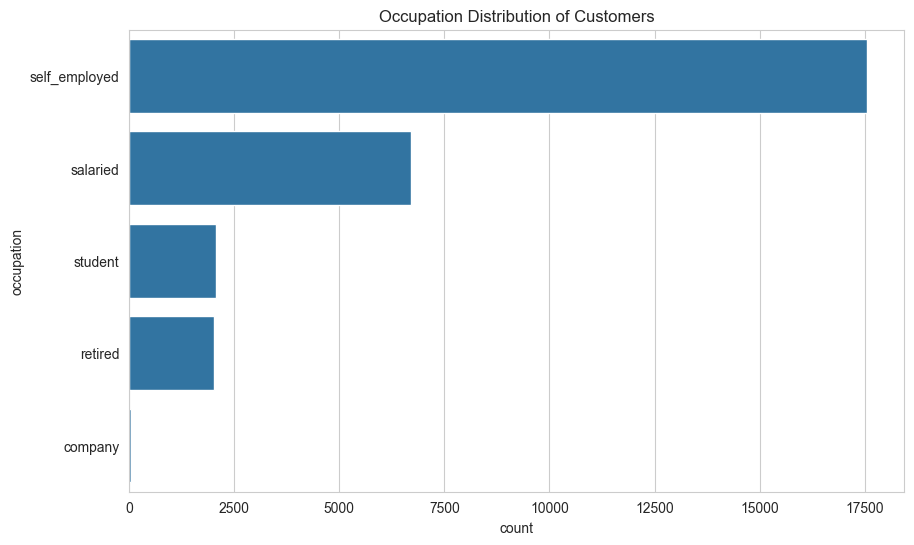

In [11]:
sns.countplot(y="occupation", data=df, order=df["occupation"].value_counts().index)
plt.title("Occupation Distribution of Customers")
plt.show()

# DEPENDENTS DISTRIBUTION

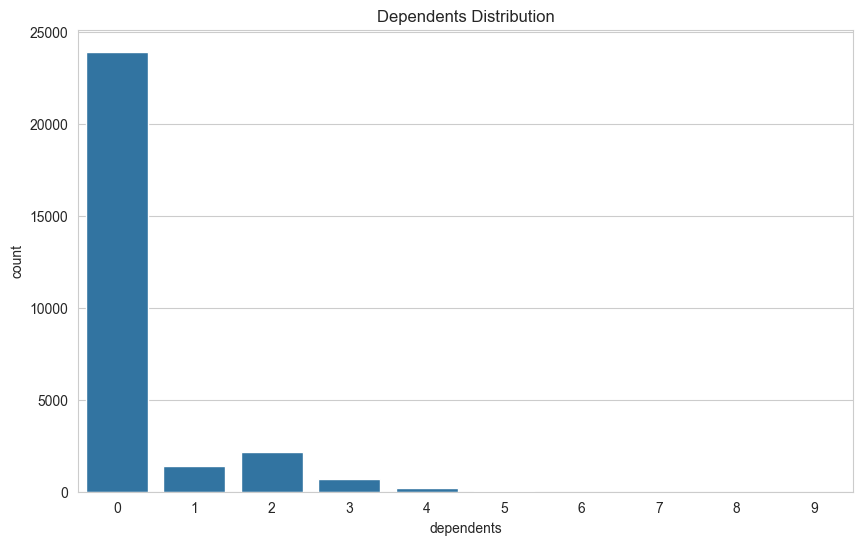

In [12]:
sns.countplot(x="dependents", data=df)
plt.title("Dependents Distribution")
plt.show()

# MARKDOWN:
# Most customers have zero dependents.

# ============================================================
# 6. FINANCIAL DISTRIBUTIONS
# ============================================================


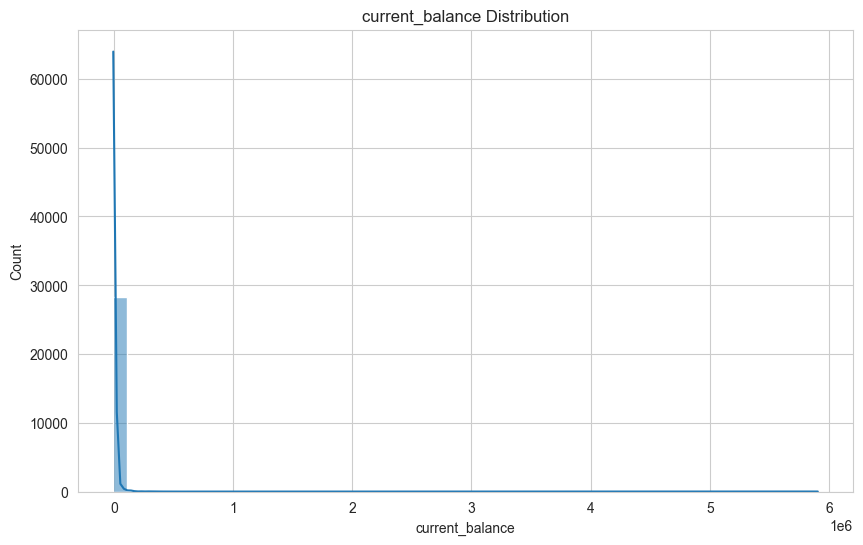

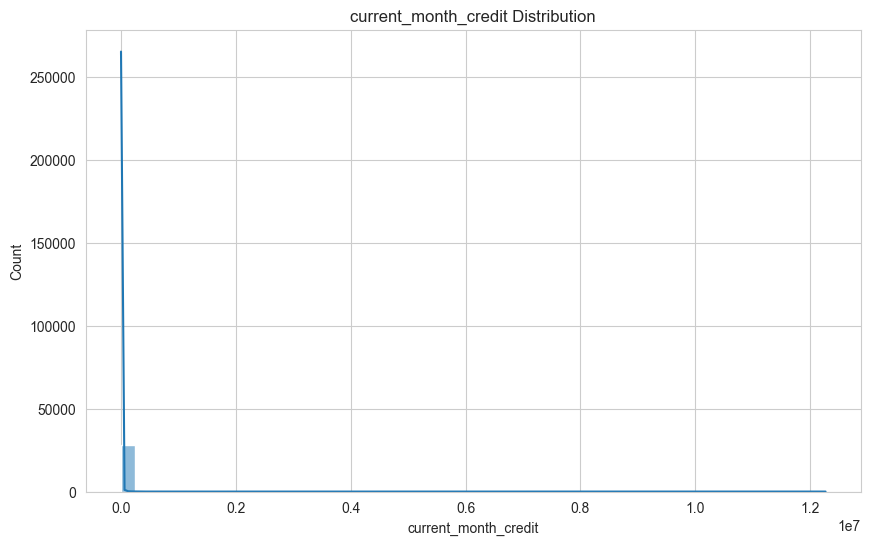

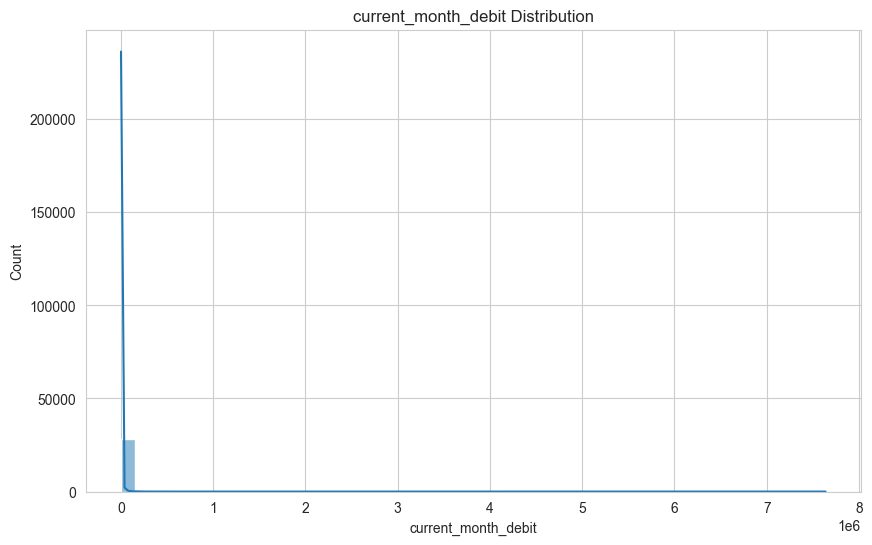

In [13]:
financial_cols = [
    "current_balance",
    "current_month_credit",
    "current_month_debit"
]

for col in financial_cols:
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
    plt.show()


# MARKDOWN:
# Financial variables are heavily right-skewed with some high-value customers.


# ============================================================
# 7. CHURN VS DEMOGRAPHICS
# ============================================================

# CHURN BY GENDER

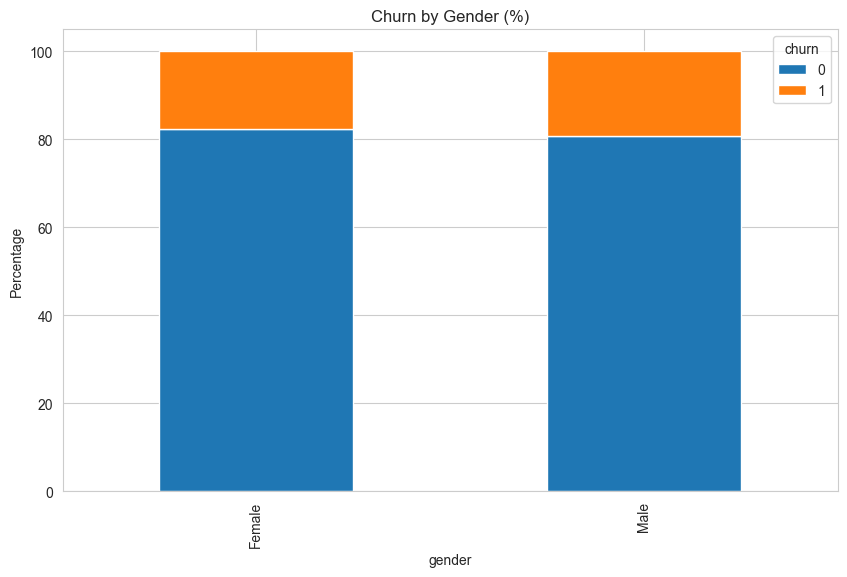

In [14]:
gender_churn = pd.crosstab(df["gender"], df["churn"], normalize="index")*100
gender_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Gender (%)")
plt.ylabel("Percentage")
plt.show()

# CHURN BY OCCUPATION


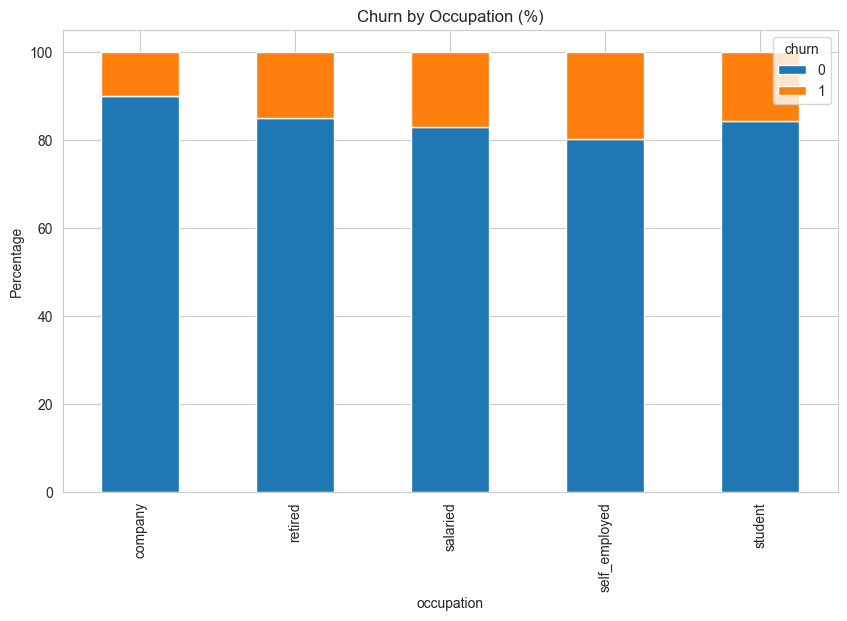

In [17]:
occ_churn = pd.crosstab(df["occupation"], df["churn"], normalize="index")*100
occ_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Occupation (%)")
plt.ylabel("Percentage")
plt.show()


# CHURN BY NET WORTH CATEGORY

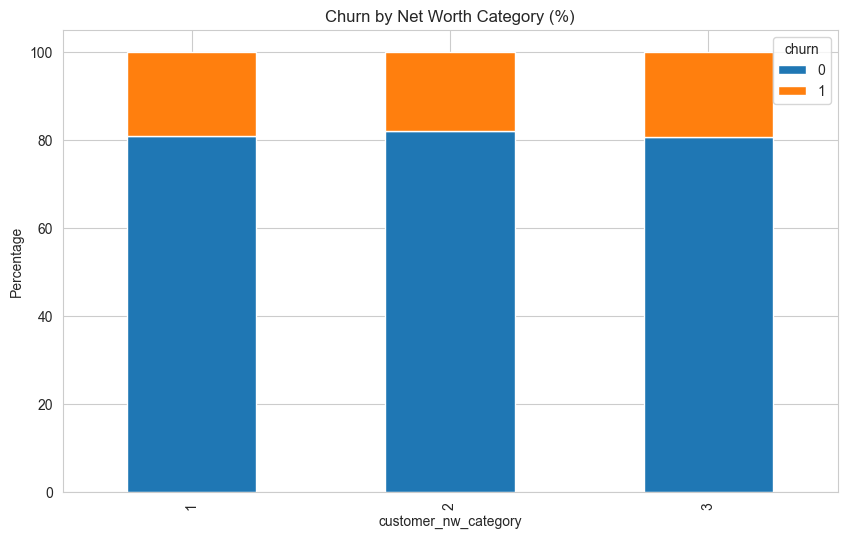

In [16]:
nw_churn = pd.crosstab(df["customer_nw_category"], df["churn"], normalize="index")*100
nw_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Net Worth Category (%)")
plt.ylabel("Percentage")
plt.show()

# ============================================================
# 8. CHURN VS AGE
# ============================================================

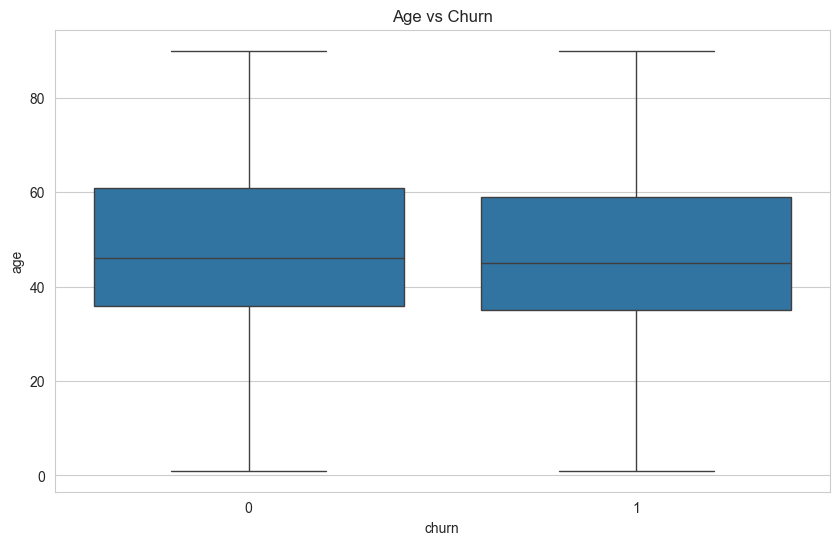

In [18]:
sns.boxplot(x="churn", y="age", data=df)
plt.title("Age vs Churn")
plt.show()

# MARKDOWN:
# Compare whether churned customers are younger or older.

# ============================================================
# 9. CHURN VS TENURE
# ============================================================


# If customer_tenure_years exists:

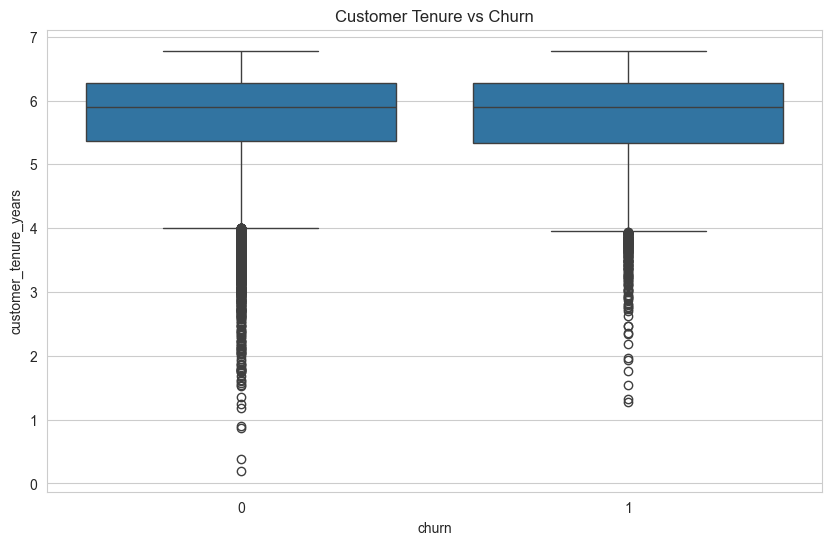

In [19]:
if "customer_tenure_years" in df.columns:
    sns.boxplot(x="churn", y="customer_tenure_years", data=df)
    plt.title("Customer Tenure vs Churn")
    plt.show()

# MARKDOWN:
# Long-term customers often churn less.

# ============================================================
# 10. CHURN VS BALANCE
# ============================================================

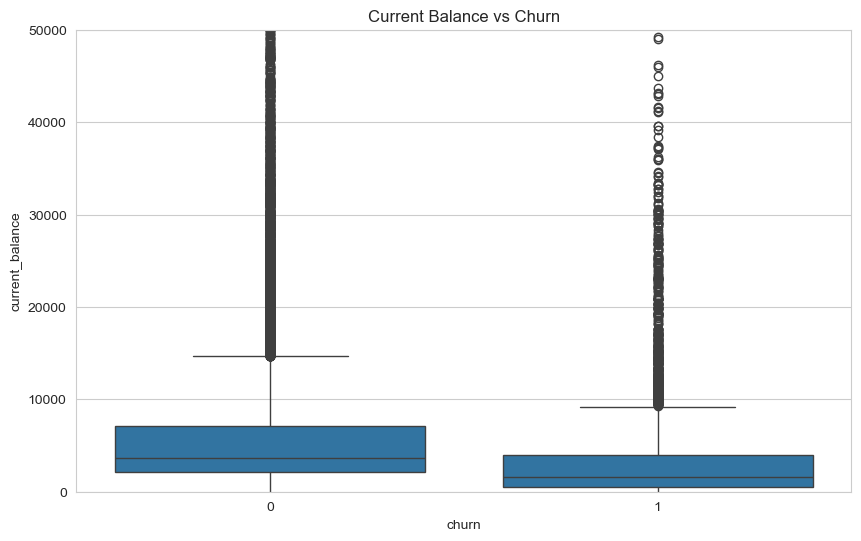

In [16]:
sns.boxplot(x="churn", y="current_balance", data=df)
plt.title("Current Balance vs Churn")
plt.ylim(0, 50000)
plt.show()

# MARKDOWN:
### Zoomed plot used because balances contain extreme values.

# ============================================================
# 11. TRANSACTION BEHAVIOR
# ============================================================

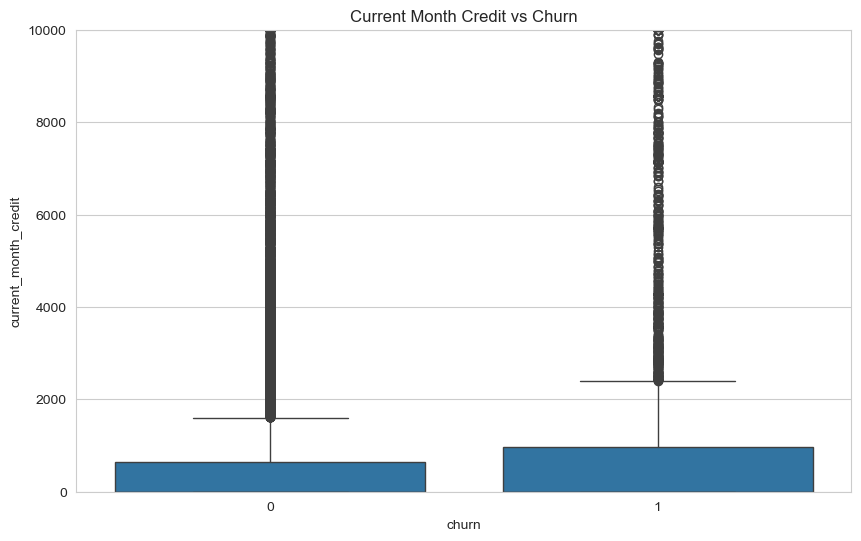

In [17]:
sns.boxplot(x="churn", y="current_month_credit", data=df)
plt.title("Current Month Credit vs Churn")
plt.ylim(0, 10000)
plt.show()

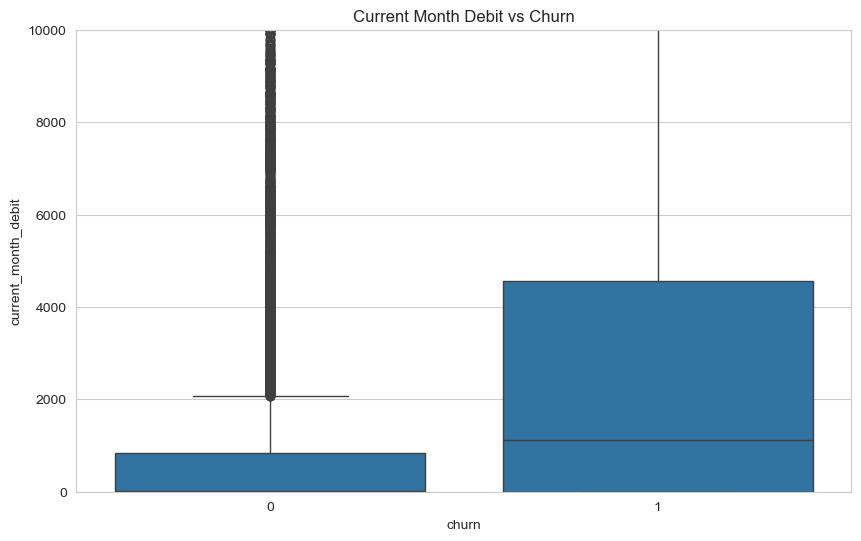

In [18]:
sns.boxplot(x="churn", y="current_month_debit", data=df)
plt.title("Current Month Debit vs Churn")
plt.ylim(0, 10000)
plt.show()

# MARKDOWN:
### Active transaction customers may churn less.

# ============================================================
# 12. CORRELATION HEATMAP
# ============================================================

In [21]:
numeric_df = df.select_dtypes(include=["int64","float64"])
numeric_df

,age,dependents,customer_nw_category,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,customer_tenure_years
0,66,0,2,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,5.76
1,35,0,2,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,6.43
2,31,0,2,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,6.01
3,90,0,2,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,6.38
4,42,2,3,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,4.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28377,10,0,2,1076.43,1076.43,2282.19,2787.70,0.30,0.30,0.30,0.30,1076.43,1076.43,0,6.37
28378,34,0,2,3844.10,4069.21,3668.83,3865.55,1.71,2.29,901.00,1014.07,3738.54,3690.32,0,4.21
28379,47,0,2,65511.97,61017.55,53444.81,21925.81,4666.84,3883.06,168.23,71.80,61078.50,57564.24,1,6.51
28380,50,3,3,1625.55,1625.55,1683.20,1857.42,0.20,0.20,0.20,0.20,1625.55,1625.55,0,4.78


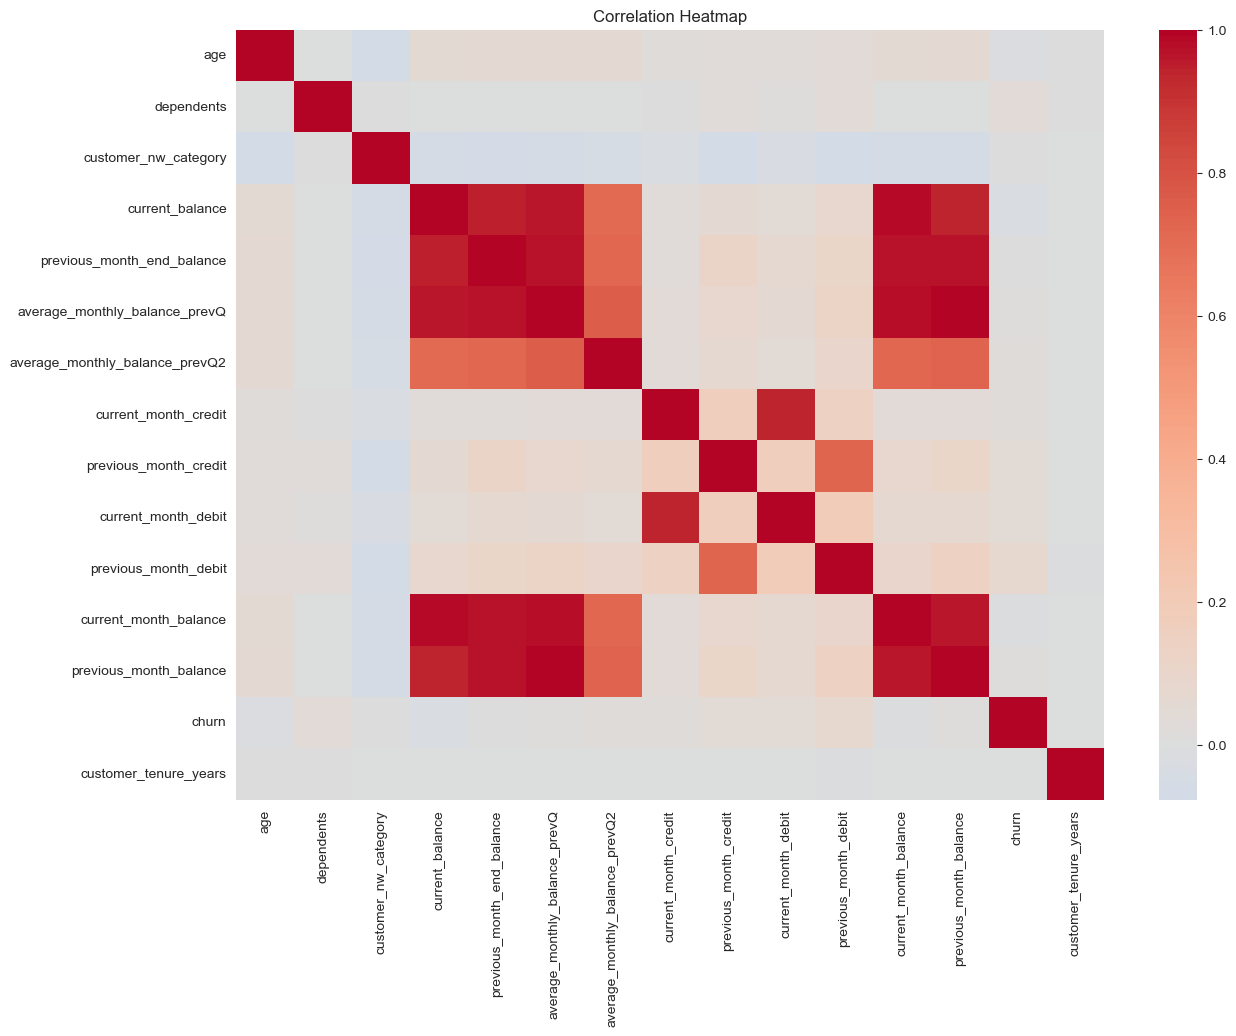

In [22]:
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# MARKDOWN:
### Use this for identifying related variables before statistical testing.


# ============================================================
# 14. OUTLIER ANALYSIS
# ============================================================

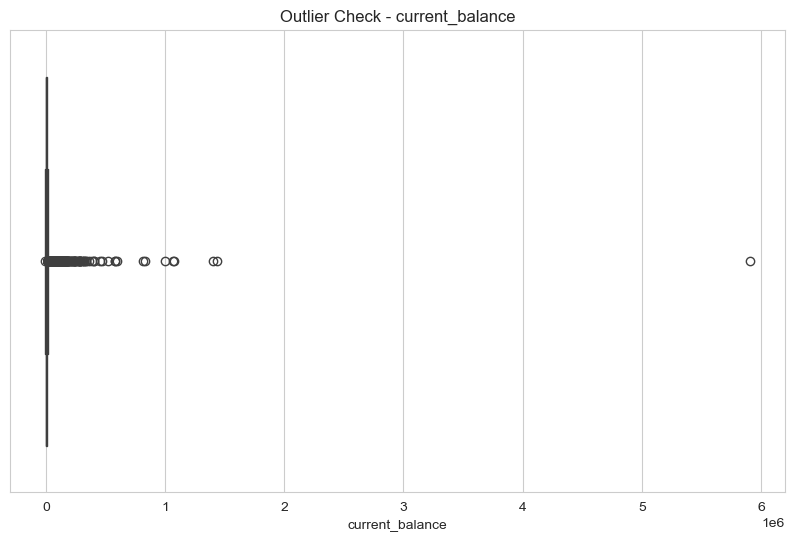

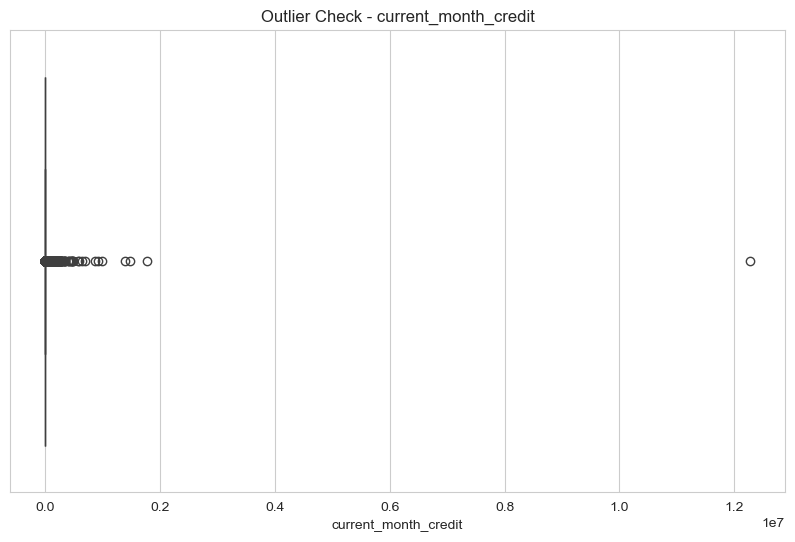

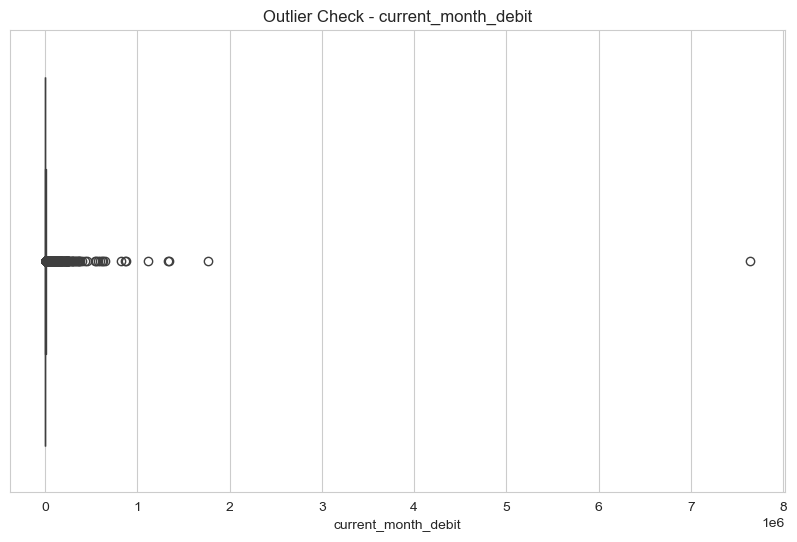

In [23]:
for col in ["current_balance","current_month_credit","current_month_debit"]:
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Check - {col}")
    plt.show()

# MARKDOWN:
# High-value outliers likely represent premium or business customers.


# ============================================================
# 15. KEY BUSINESS INSIGHTS
# ============================================================

# MARKDOWN:

"""
# Final Insights

1. Overall churn rate is around 18.5%.

2. Certain occupations show higher churn than others.

3. Lower-balance customers appear more likely to churn.

4. Customers with stronger transaction activity tend to remain active.

5. Longer-tenure customers show stronger retention.

6. Financial variables are highly skewed, indicating a small group of high-value customers.
"""